# Module 3

## Null/Alternate, Errors, T-tests & Student's t

- Null hypothesis (H₀) and alternate hypothesis (H₁)  
- Type I (α) and Type II (β) errors, power  
- One-tailed tests  
- Two-tailed tests  
- Student **t** probability distribution (PDF, CDF, simulation)

## Setup
We import common libraries and set a random seed.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

plt.style.use('seaborn-v0_8-whitegrid')

# Try SciPy (optional). If unavailable, we'll use robust fallbacks.
try:
    import scipy.stats as st
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

rng = np.random.default_rng(2025)

## Hypotheses & Errors — Concepts
- **Null hypothesis (H₀)**: baseline claim (e.g., population mean μ equals a reference).  
- **Alternate hypothesis (H₁)**: competing claim (e.g., μ is greater, less, or not equal).  
- **Type I error (α)**: rejecting H₀ when H₀ is true.  
- **Type II error (β)**: failing to reject H₀ when H₁ is true.  
- **Power**: 1 − β (probability to correctly reject H₀ when H₁ is true).

We will illustrate these with one-sample t-tests.


## Student's t Distribution
The **Student's t** distribution with degrees of freedom `ν` is used when **σ is unknown** and we estimate it from the sample.
We implement:
- PDF (closed form)
- CDF (via SciPy if available; else numerical integration of the PDF)
- Critical values `t*` for a desired confidence level or tail probability.


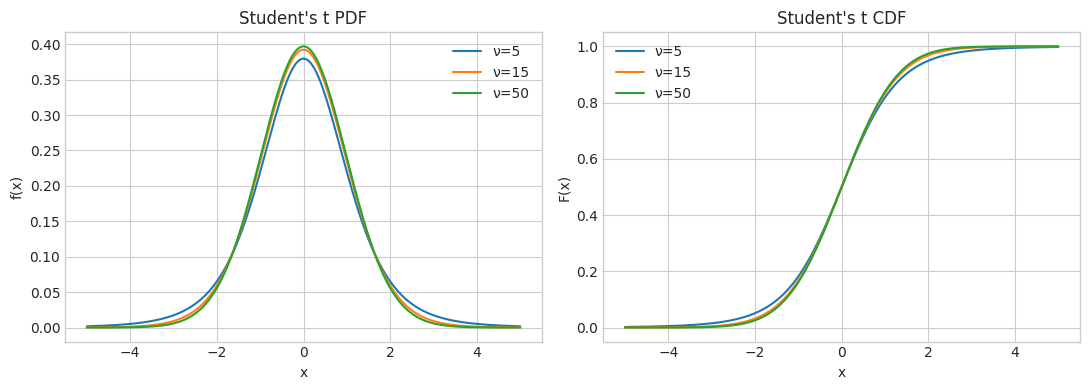

In [2]:
# t-distribution PDF using gamma function
# f(x; ν) = Γ((ν+1)/2) / (sqrt(νπ) Γ(ν/2)) * (1 + x^2/ν)^(-(ν+1)/2)

def t_pdf(x, nu):
    return (math.gamma((nu+1)/2) / (math.sqrt(nu*math.pi) * math.gamma(nu/2))) * (1 + (x**2)/nu) ** (-(nu+1)/2)

# CDF: use SciPy if available; else numerically integrate PDF via trapezoidal rule over a grid

def t_cdf(x, nu):
    if SCIPY_AVAILABLE:
        return st.t.cdf(x, df=nu)
    # Numerical integration from -L to x
    L = 10  # integration bounds
    grid = np.linspace(-L, x, 4000) if x >= -L else np.linspace(x, -L, 4000)
    vals = np.array([t_pdf(t, nu) for t in grid])
    area = np.trapz(vals, grid)
    # If x < -L, area computed backwards; ensure proper area from -L to x
    if x < -L:
        # Total area from -L to -L is 0; adjust using symmetry approximation
        pass
    # Approximate the missing tail from -inf to -L using SciPy if available, else assume negligible
    return area

# Compute symmetric critical t* for two-tailed alpha: returns positive t*

def t_star_two_tailed(alpha, nu):
    if SCIPY_AVAILABLE:
        return st.t.ppf(1 - alpha/2, df=nu)
    # numeric inversion using bisection on CDF
    target = 1 - alpha/2
    lo, hi = 0.0, 10.0
    for _ in range(80):
        mid = (lo + hi) / 2
        if t_cdf(mid, nu) < target:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2

# One-tailed critical value (right tail)

def t_star_one_tailed(alpha, nu):
    if SCIPY_AVAILABLE:
        return st.t.ppf(1 - alpha, df=nu)
    target = 1 - alpha
    lo, hi = 0.0, 10.0
    for _ in range(80):
        mid = (lo + hi) / 2
        if t_cdf(mid, nu) < target:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2

# Visualize PDF & CDF for a few ν
nus = [5, 15, 50]
x = np.linspace(-5, 5, 400)
fig, ax = plt.subplots(1, 2, figsize=(11,4))
for nu in nus:
    ax[0].plot(x, [t_pdf(v, nu) for v in x], label=f"ν={nu}")
ax[0].set_title("Student's t PDF"); ax[0].set_xlabel('x'); ax[0].set_ylabel('f(x)'); ax[0].legend()

for nu in nus:
    if SCIPY_AVAILABLE:
        ax[1].plot(x, st.t.cdf(x, df=nu), label=f"ν={nu}")
    else:
        ax[1].plot(x, [t_cdf(v, nu) for v in x], label=f"ν={nu}")
ax[1].set_title("Student's t CDF"); ax[1].set_xlabel('x'); ax[1].set_ylabel('F(x)'); ax[1].legend()
plt.tight_layout(); plt.show()

## One-sample t-tests
We test a population mean when **σ unknown** using the t statistic:
\[ t = \frac{\bar{x} - \mu_0}{s/\sqrt{n}} \]

We'll demonstrate:
- **Two-tailed** test: H₀: μ = μ₀ vs H₁: μ ≠ μ₀  
- **Right-tailed** test: H₀: μ ≤ μ₀ vs H₁: μ > μ₀  
- **Left-tailed** test: H₀: μ ≥ μ₀ vs H₁: μ < μ₀


In [3]:
# Generate a sample from a Normal population with unknown sigma
true_mu = 100
true_sigma = 15
n = 25
sample = rng.normal(loc=true_mu, scale=true_sigma, size=n)

xbar = sample.mean()
s = sample.std(ddof=1)
mu0 = 95  # reference mean

t_stat = (xbar - mu0) / (s / math.sqrt(n))
nu = n - 1

print(f"x̄ = {xbar:.2f}, s = {s:.2f}, n = {n}, t-stat = {t_stat:.3f}, df = {nu}")

# p-values using SciPy if available; else approximate via numerical CDF
if SCIPY_AVAILABLE:
    p_two = 2 * (1 - st.t.cdf(abs(t_stat), df=nu))
    p_right = 1 - st.t.cdf(t_stat, df=nu)
    p_left = st.t.cdf(t_stat, df=nu)
else:
    # Numerical approximations
    def tcdf(val):
        return t_cdf(val, nu)
    p_two = 2 * (1 - tcdf(abs(t_stat)))
    p_right = 1 - tcdf(t_stat)
    p_left = tcdf(t_stat)

print(f"Two-tailed p-value: {p_two:.4f}")
print(f"Right-tailed p-value: {p_right:.4f}")
print(f"Left-tailed p-value: {p_left:.4f}")

alpha = 0.05
# Critical values
if SCIPY_AVAILABLE:
    tcrit_two = st.t.ppf(1 - alpha/2, df=nu)
    tcrit_right = st.t.ppf(1 - alpha, df=nu)
    tcrit_left = st.t.ppf(alpha, df=nu)
else:
    tcrit_two = t_star_two_tailed(alpha, nu)
    tcrit_right = t_star_one_tailed(alpha, nu)
    tcrit_left = -tcrit_right

print(f"Two-tailed critical ±t*: ±{tcrit_two:.3f}")
print(f"Right-tailed critical t*: {tcrit_right:.3f}")
print(f"Left-tailed critical t*: {tcrit_left:.3f}")

# Decisions
reject_two = abs(t_stat) > tcrit_two
reject_right = t_stat > tcrit_right
reject_left = t_stat < tcrit_left

print(f"Reject H0 (two-tailed)? {reject_two}")
print(f"Reject H0 (right-tailed)? {reject_right}")
print(f"Reject H0 (left-tailed)? {reject_left}")

x̄ = 97.50, s = 18.63, n = 25, t-stat = 0.672, df = 24
Two-tailed p-value: 0.5079
Right-tailed p-value: 0.2540
Left-tailed p-value: 0.7460
Two-tailed critical ±t*: ±2.064
Right-tailed critical t*: 1.711
Left-tailed critical t*: -1.711
Reject H0 (two-tailed)? False
Reject H0 (right-tailed)? False
Reject H0 (left-tailed)? False


## Visualizing Rejection Regions
Below we visualize the **t** distribution with df = n−1 and mark rejection regions for α = 0.05.


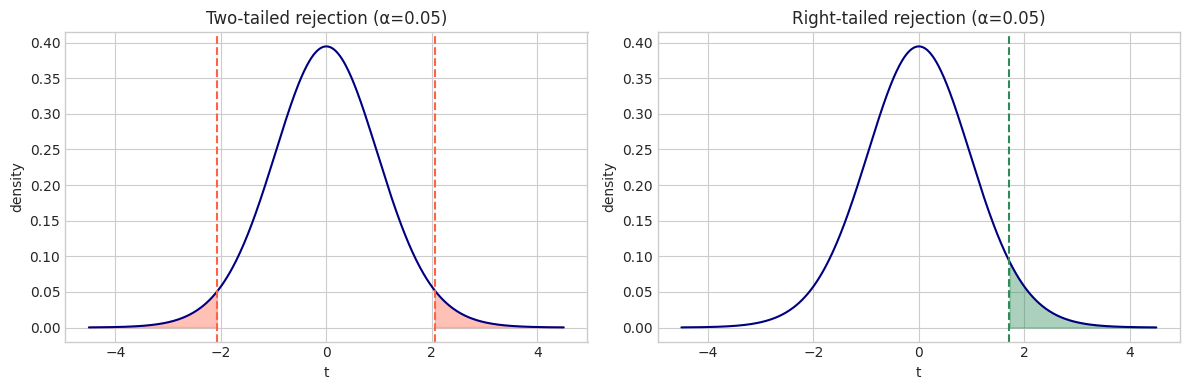

In [4]:
nu = n - 1
x = np.linspace(-4.5, 4.5, 500)
if SCIPY_AVAILABLE:
    pdf = st.t.pdf(x, df=nu)
else:
    pdf = np.array([t_pdf(v, nu) for v in x])

alpha = 0.05
if SCIPY_AVAILABLE:
    tcrit_two = st.t.ppf(1 - alpha/2, df=nu)
    tcrit_right = st.t.ppf(1 - alpha, df=nu)
else:
    tcrit_two = t_star_two_tailed(alpha, nu)
    tcrit_right = t_star_one_tailed(alpha, nu)

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(x, pdf, color='navy')
ax[0].fill_between(x, 0, pdf, where=(x<=-tcrit_two) | (x>=tcrit_two), color='tomato', alpha=0.4)
ax[0].axvline(-tcrit_two, color='tomato', ls='--'); ax[0].axvline(tcrit_two, color='tomato', ls='--')
ax[0].set_title('Two-tailed rejection (α=0.05)'); ax[0].set_xlabel('t'); ax[0].set_ylabel('density')

ax[1].plot(x, pdf, color='navy')
ax[1].fill_between(x, 0, pdf, where=(x>=tcrit_right), color='seagreen', alpha=0.4)
ax[1].axvline(tcrit_right, color='seagreen', ls='--')
ax[1].set_title('Right-tailed rejection (α=0.05)'); ax[1].set_xlabel('t'); ax[1].set_ylabel('density')
plt.tight_layout(); plt.show()

## Type I & Type II Errors via Simulation (Power)
We estimate **Type I error (α)** and **Type II error (β)** for a one-sample **right-tailed** t-test by Monte Carlo.
- H₀: μ ≤ μ₀; choose μ₀
- Under H₀ (true μ = μ₀), the proportion of rejections estimates **α**.
- Under H₁ (true μ = μ₀ + δ), the proportion of **non-rejections** estimates **β**; power = 1 − β.


   delta     power      beta
0      0  0.046000  0.954000
1      2  0.141000  0.859000
2      4  0.309000  0.691000
3      6  0.536333  0.463667


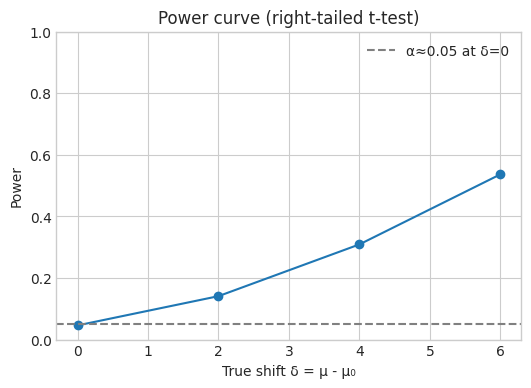

Interpretation: At δ=0 (H0 true), power≈α; for larger δ, power increases and β decreases.


In [5]:
def simulate_power_right_t(mu0=100, sigma=15, n=20, alpha=0.05, delta_list=(0, 2, 4, 6), B=5000):
    nu = n - 1
    if SCIPY_AVAILABLE:
        tcrit = st.t.ppf(1 - alpha, df=nu)
    else:
        tcrit = t_star_one_tailed(alpha, nu)
    results = []
    for delta in delta_list:
        rejections = 0
        for _ in range(B):
            sample = rng.normal(loc=mu0 + delta, scale=sigma, size=n)
            xbar = sample.mean()
            s = sample.std(ddof=1)
            t_stat = (xbar - mu0) / (s / math.sqrt(n))
            if t_stat > tcrit:
                rejections += 1
        power = rejections / B
        beta = 1 - power
        results.append((delta, power, beta))
    return pd.DataFrame(results, columns=['delta', 'power', 'beta'])

mu0 = 100
n = 20
alpha = 0.05
sigma = 15

power_tbl = simulate_power_right_t(mu0=mu0, sigma=sigma, n=n, alpha=alpha, delta_list=(0, 2, 4, 6), B=3000)
print(power_tbl)

plt.figure(figsize=(6,4))
plt.plot(power_tbl['delta'], power_tbl['power'], marker='o')
plt.axhline(0.05, color='gray', ls='--', label='α≈0.05 at δ=0')
plt.title('Power curve (right-tailed t-test)')
plt.xlabel('True shift δ = μ - μ₀'); plt.ylabel('Power')
plt.ylim(0,1); plt.legend(); plt.grid(True)
plt.show()

print("Interpretation: At δ=0 (H0 true), power≈α; for larger δ, power increases and β decreases.")

## Wrap-up
This notebook demonstrated:
- Formulating **H₀/H₁** and identifying **Type I/II errors**
- Running **one-tailed** and **two-tailed** one-sample **t-tests**
- Visualizing rejection regions
- Exploring the **Student's t** distribution
- Estimating **power** and **β** via simulation

Feel free to change `n`, `α`, `μ₀`, and `σ` to see how decisions and power are affected.
